# Designing Agentic Systems with LangChain

## Chapter 1 - The Essentials of LangChain agents

### Section 1.1 - Agents in Langchain

In [1]:
import sys
import os

# Use current working directory and go one level up
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)

# Now you can import your config
from config import api_key

#### Creating a ReAct agent

Now that you've learned the basic components of LangChain, you'll jump right in and create a ReAct agent that can count how many 'r's there are in any word with the `tool count_r_in_word`.

The following have been loaded for you: `tool`, `ChatOpenAI`, `create_react_agent`, `math`, and `model`.

In [2]:
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.prebuilt import create_react_agent
import math

# LLM Setup
model = ChatOpenAI(openai_api_key=api_key, model='gpt-4o-mini')

@tool
def count_r_in_word(input: str) -> int:
    """Counts the number of 'r's in a given word."""
    
    # Count the occurrences of 'r' (both lowercase and uppercase)
    return input.lower().count('r')

In [3]:
# Create the agent
app = create_react_agent(model=model, tools=[count_r_in_word])

# Create a query
query = "How many r's are in the word 'Terrarium'?"

# Invoke the agent and store the response
response = app.invoke({"messages": [("human", query)]})

# Print the agent's response
print(response['messages'][-1].content)

The word "Terrarium" contains 3 'r's.


### Section 1.2 - Building custom tools

#### Create a tool for math calculations

It's time to build your tool. Let's imagine you run a small construction company and need to calculate the length of one side of a roof. If you know the lengths of two beams that support the roof at a right angle, you can use their lengths to calculate the length of the roof using the hypotenuse formula below.

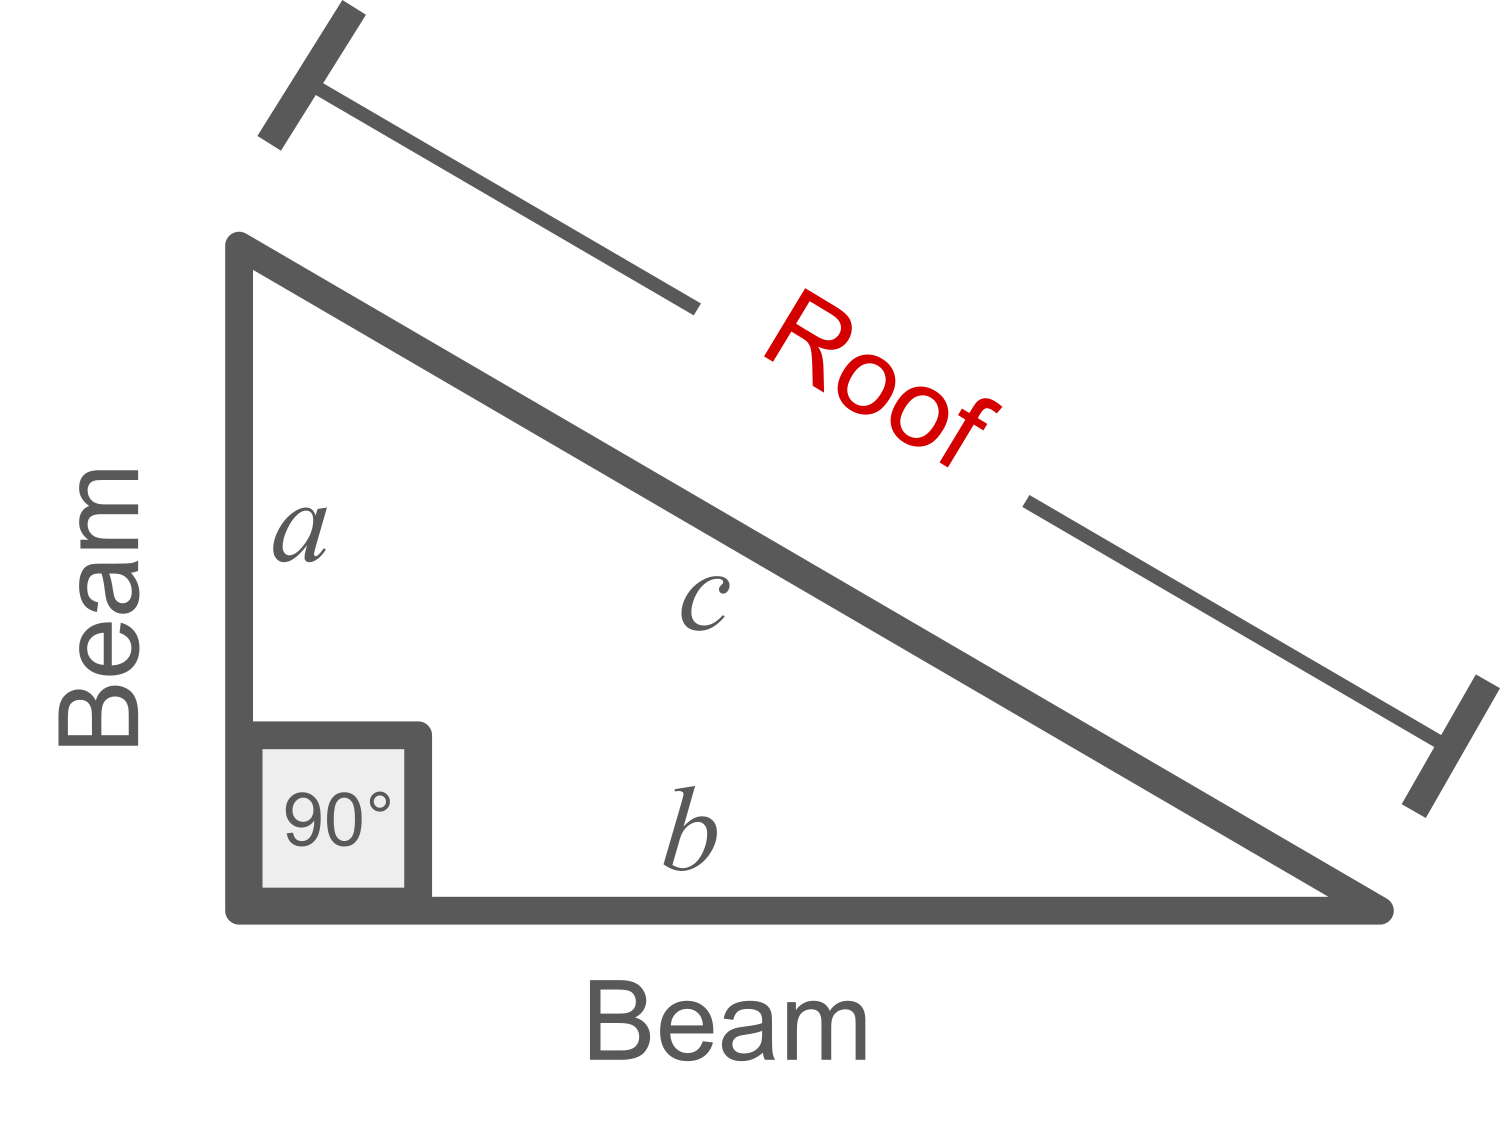

In [4]:
# Define this math function as a tool
@tool
def hypotenuse_length(input: str) -> float:
    """Calculates the length of the hypotenuse of a right-angled triangle given the lengths of the other two sides."""
    
    # Split the input string to get the lengths of the triangle
    sides = input.split(',')
    
    # Convert the input values to floats, removing extra spaces
    a = float(sides[0].strip())
    b = float(sides[1].strip())
    
    # Square each of the values, add them together, and find the square root 
    return math.sqrt(a**2 + b**2)

#### Integrating custom tools and queries
You now have a custom math tool for calculating roof length. You can integrate it with an agentic workflow by creating a variable called `query` that accepts the user's natural language question as a string. Your tool is already loaded as `hypotenuse_length`, as well as your `model`.

In [5]:
# Create a list variable and pass in your tool
tools = [hypotenuse_length]

# Create a query using natural language
query = "What is the hypotenuse length of a triangle with side lengths of 10 and 12?"

# Pass in the hypotenuse length tool and create the agent
app = create_react_agent(model, tools)

# Invoke the agent and print the response
response = app.invoke({"messages": [("human", query)]})
print(response['messages'][-1].content)

The length of the hypotenuse of a triangle with side lengths of 10 and 12 is approximately 15.62.


### Section 1.3 - Conversation with a ReAct agent

In [6]:
from langchain_core.messages import HumanMessage, AIMessage

#### Conversation setup

Now that you have a custom tool to help you calculate the length of a roof, you can set your agent's outputs to respond to your entered query. By slightly modifying your print statements, you can directly compare your query and your agent's response to ensure accuracy. Your `tools` and `query` have already been set up and your `model` is ready to use.

In [7]:
tools = [hypotenuse_length]
query = "What is the value of the hypotenuse for a triangle with sides 3 and 5?"

# Create the ReAct agent
app = create_react_agent(model, tools)

# Invoke the agent with a query and store the messages
response = app.invoke({"messages": [("human", query)]})

# Define and print the input and output messages
print({
    "user_input": query,
    "agent_output": response["messages"][-1].content
})

{'user_input': 'What is the value of the hypotenuse for a triangle with sides 3 and 5?', 'agent_output': 'The length of the hypotenuse for a triangle with sides 3 and 5 is approximately 5.83.'}


#### Ask questions about conversation history
With a basic ReAct agent in LangChain, you can ask follow-up questions by keeping the agent's conversation history. Since the LLM has access to all previous messages, you can now ask new questions, and the agent can use the full message context to respond.

You'll now ask a follow-up question about the sides of a different triangle.

To be able to use the HumanMessage and AIMessage capabilities, the following modules have already been imported for you: `HumanMessage`, `AIMessage`.

In [8]:
from langchain_core.messages import HumanMessage, AIMessage

In [9]:
message_history = response["messages"]
new_query = "What about one with sides 12 and 14?"

# Invoke the app with the full message history
response = app.invoke({"messages": message_history + [("human", new_query)]})

# Extract the human and AI messages from the result
filtered_messages = [msg for msg in response["messages"] if isinstance(msg, (HumanMessage, AIMessage)) and msg.content.strip()]

# Pass the new query as input and print the final outputs
print({
    "user_input": new_query,
    "agent_output": [f"{msg.__class__.__name__}: {msg.content}" for msg in filtered_messages]
})

{'user_input': 'What about one with sides 12 and 14?', 'agent_output': ['HumanMessage: What is the value of the hypotenuse for a triangle with sides 3 and 5?', 'AIMessage: The length of the hypotenuse for a triangle with sides 3 and 5 is approximately 5.83.', 'HumanMessage: What about one with sides 12 and 14?', 'AIMessage: The length of the hypotenuse for a triangle with sides 12 and 14 is approximately 18.44.']}


In [10]:
for msg in response['messages']:
    if msg.content:
        print(msg.content.strip())

What is the value of the hypotenuse for a triangle with sides 3 and 5?
5.830951894845301
The length of the hypotenuse for a triangle with sides 3 and 5 is approximately 5.83.
What about one with sides 12 and 14?
18.439088914585774
The length of the hypotenuse for a triangle with sides 12 and 14 is approximately 18.44.


In [11]:
for msg in response['messages']:
    print(msg.__class__.__name__)

HumanMessage
AIMessage
ToolMessage
AIMessage
HumanMessage
AIMessage
ToolMessage
AIMessage


## Chapter 2 - Building Chatbots with LangChain

In [12]:
# Modules for structuring text
from typing import Annotated
from typing_extensions import TypedDict

# LangGraph modules for defining graphs
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Module for setting up OpenAI
from langchain_openai import ChatOpenAI

#### Graph and agent states
You've been commissioned to create a basic chatbot that can answer questions within a high school education app. The school would like you to use a version of ChatGPT from OpenAI as its LLM. You've decided you can efficiently manage this task using LangGraph to build a chatbot agent using nodes. First, you'll define an agent `State()` to store the agent's data, and set up a `StateGraph()` object to manage the agent's workflow.

The required modules have already been imported for this exercise and those that will follow:

```python
from langchain_openai import ChatOpenAI
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
```

In [17]:
llm = ChatOpenAI(model="gpt-4o-mini", api_key=api_key)

In [18]:
# Define the State
class State(TypedDict):

    # Define message with metadata
    messages: Annotated[list, add_messages]

# Initialize StateGrapth
graph_builder = StateGraph(State)

Great start! When building agentic workflows, agent states help store and update the agent's data, while the graph state organizes the order of tasks. LangGraph helps you easily modify workflows by using a low-code framework. Next up, you'll learn how to add functions as nodes to you graph!

#### Adding nodes and edges
Now that your `StateGraph()` is ready, it's time to add your chatbot's nodes to the graph! The pre-built `START` and `END` nodes are directly imported from LangGraph, so you'll have just one chatbot node to create. You'll also define the edges that determine the direction of your chatbot's conversation, from start to finish. Once your nodes and edges are added, you'll compile the graph to get it ready to run with a query.

In [19]:
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

# Add chatbot node to the graph
graph_builder.add_node("chatbot", chatbot)

graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

# Compile the graph to prepare for 
# execution
graph = graph_builder.compile()


Nice work adding your graph nodes and defining your edges! The ability to control your nodes and edges allows you to quickly change the functionality of your agent. Now that you've built your full chatbot as a graph, it's time to try it out!

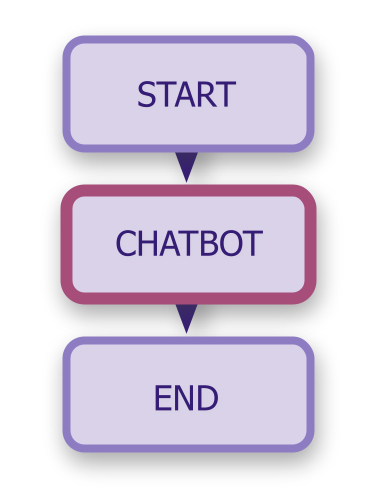

### Section 2.2 Generating chatbot responses

In [32]:
# Define a function to execute the chatbot based on user input
def stream_graph_updates(user_input: str):
    
    # Start streaming events from the graph with the user's input
    for event in graph.stream({"messages": [("user", user_input)]}):
        
        # Retrieve and print the chatbot node responses
        for item in event.values():
            print("Agent:", item["messages"])

# Define the user query and run the chatbot
user_query = "Who is Ada Lovelace?"
stream_graph_updates(user_query)

Agent: [AIMessage(content='Ada Lovelace, born Ada Augusta Byron on December 10, 1815, is often regarded as one of the first computer programmers. She was the daughter of the famous poet Lord Byron and mathematician Annabella Milbanke. Lovelace is best known for her work on Charles Babbage\'s early mechanical general-purpose computer, the Analytical Engine.\n\nIn 1843, she translated an article written by the Italian mathematician Luigi Federico Federico Federico Francesco (often referred to as "Countess") and supplemented it with her own notes, which included a detailed description of an algorithm for the Analytical Engine to compute Bernoulli numbers. This work is considered one of the first instances of computer programming.\n\nLovelace\'s visionary insights into the capabilities of computers extended beyond mere calculation; she speculated about their potential to manipulate symbols and create music and graphics, anticipating the multifaceted uses of computers in ways that were far 

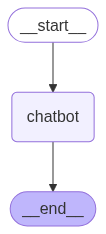

In [50]:
# Try generating and displaying the diagram of the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))

# Return an exception if the generation fails  
except Exception:
    print("Diagram generation requires additional dependencies.")

### Section 2.3 Adding external tools to a chatbot

#### Build a Wikipedia tool
The school administration is quite happy with your work! They would like to make the chatbot even more powerful by incorporating external resources. You suggest equipping the chatbot with access to Wikipedia. The administration agrees to extend your commission, so you decide to build a tool for the chatbot using the Wikipedia API.

The following modules have been imported for you to get started: `WikipediaQueryRun`, `WikipediaAPIWrapper`

In [63]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

# Initialize Wikipedia API wrapper to fetch top 1 result
api_wrapper = WikipediaAPIWrapper(top_k_results=1)

# Create a Wikipeida query tool using the API wrapper
wikipedia_tool = WikipediaQueryRun(api_wrapper=api_wrapper)
tools = [wikipedia_tool]

In [64]:
# Bind the wikipedia tool to the language mode
llm_with_tools = llm.bind_tools(tools)

# Modify chatbot function to respond with Wikipedia
def chatbot(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]}

#### Add a tool to a graph

You've got your Wikipedia tool ready to go. Now it's time to incorporate it into your chatbot's graph workflow! You'll modify the nodes and edges in the graph workflow to incorporate the tool as an additional node. You'll set up the graph so that the chatbot can use the tool only when needed depending on the user's query. To manage your tool node and its associated edges, the following modules have been imported for you. The `wikipedia_tool` you built is also available in your environment. Once the graph build is complete, your graph will be visualized for you as a LangGraph diagram.

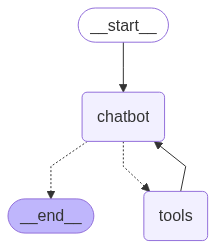

In [78]:
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from IPython.display import Image, display

# Re-create a new, empty graph
graph_builder = StateGraph(State)

# Add chatbot node to the graph
graph_builder.add_node("chatbot", chatbot)

# Create a ToolNode to handle tool calls
tool_node = ToolNode(tools=[wikipedia_tool])
graph_builder.add_node("tools", tool_node)

# Conditional edges: chatbot -> (tools OR end)
graph_builder.add_conditional_edges("chatbot", tools_condition, ["tools", END])

# Tools loop back into chatbot
graph_builder.add_edge("tools", "chatbot")

# Entry point
graph_builder.add_edge(START, "chatbot")

# Compile
graph = graph_builder.compile()

# Show the graph
display(Image(graph.get_graph().draw_mermaid_png()))


### Section 2.4 - Adding memory to the graph

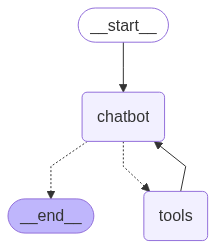

In [80]:
# Produce the chatbot graph
display(Image(graph.get_graph().draw_mermaid_png()))

### Section 2.4 - Adding memory and conversation

#### Visualize the graph and return tool outputs
Your chatbot's graph is ready! First, you'll visualize the graph diagram to ensure that it's been correctly set up. Then, you'll build a function that allows you to run the chatbot as an application, passing in a question as a string and then obtaining the response. If the LLM alone is insufficient, the chatbot can access Wikipedia using the API tool to respond.

The graph has already been compiled for you.

#### Adding graph memory
Excellent! Your chatbot can use Wikipedia to answer questions based on the the user's query. Now you can take things a step further by allowing your users to ask follow up questions! To do this, you'll first need to enable memory within your chatbot. Memory will allow your chatbot access to the full context of the conversation so it can handle follow up conversations.

In [81]:
# Import the modules for saving memory
from langgraph.checkpoint.memory import MemorySaver

# Modify the graph with memory checkpointing
memory = MemorySaver()

# Compile the graph passing in memory
graph = graph_builder.compile(checkpointer=memory)

#### Using graph memory for conversation

Now that your chatbot has access to memory, you can stream its responses to follow up questions. Note that your follow up questions will need no extra context as the chatbot can access the full conversation stored in its memory. The questions have already been set up for you.

In [88]:
def stream_memory_responses(user_input: str):
    config = {"configurable": {"thread_id": "single_session_memory"}}
    
    # Stream the events in the graph
    for event in graph.stream({"messages": [("user", user_input)]}, config):
        
        # Return the agent's last response
        for value in event.values():
            if "messages" in value and value["messages"]:
                print("Agent:", value["messages"])

stream_memory_responses("Tell me about the Eiffel Tower.")
stream_memory_responses("Who built it?")
stream_memory_responses("What is the time?")

Agent: [AIMessage(content='The Eiffel Tower is a wrought-iron lattice tower situated on the Champ de Mars in Paris, France. It was designed by the engineer Gustave Eiffel and constructed between 1887 and 1889 as the centerpiece for the 1889 World\'s Fair, which celebrated the centennial anniversary of the French Revolution. \n\nLocally known as "La dame de fer" (French for "Iron Lady"), the tower faced criticism from prominent artists and intellectuals in France during its construction. However, it has since evolved into a global cultural icon of France and one of the most recognizable structures worldwide. In 2022, it welcomed 5,889,000 visitors, making it the most visited monument in the world with an entrance fee.\n\nStanding at 330 meters (1,083 feet) tall, the Eiffel Tower is approximately the height of an 81-story building and is the tallest structure in Paris. The base of the tower is square, measuring 125 meters (410 feet) on each side. Upon its completion, it surpassed the Was

## Chapter 3 - Build Dynamic Chat Agents

### Section 3.1 - Defining multiple tools

#### Build a tool that invokes the LLM

The school administration loves your work on the education app with the Wikipedia search agent. They would love you to expand the app even further with some additional tools. Here, you'll build a tool called `historical_events()` that's able to invoke the LLM within the body of the tool to answer questions about famous dates in history. The Wikipedia tool has already been set up for you and the `llm` is available in your environment.

In [84]:
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools import WikipediaQueryRun

# Initialize Wikipedia API wrapper to fetch top 1 result
api_wrapper = WikipediaAPIWrapper(top_k_results=1)

# Create a Wikipeida query tool using the API wrapper
wikipedia_tool = WikipediaQueryRun(api_wrapper=api_wrapper)
tools = [wikipedia_tool]

In [85]:
# Use a decorator to label the tool and set the input format to string
@tool
def historical_events(date_input: str) -> str:
    """Provide a list of important historical events for a given date in any format."""
    try:

      	# Invoke the LLM to interpret the date and generate historical events
        response = llm.invoke(f"List important historical events that occurred on {date_input}.")
        
        # Return the response
        return response.content

    # Set an exception block for errors in retrieval
    except Exception as e:
        return f"Error retrieving events: {str(e)}"

#### Build a tool with Python code

Now that your chatbot has the historical events and Wikipedia tools at its disposal, the school administration would also like you to add a grammar tool for the English curriculum. They've asked you to build a palindrome-checker that determines if an input phrase or word reads the same even when it is typed in reverse. The students should be able to use this tool to test different types of input strings to check if they are palindromes, such as "level" or "never odd or even", which both read the same when typed backwards.

In [86]:
@tool
# Set input format to string
def palindrome_checker(text: str) -> str:
    """Check if a word or phrase is a palindrome."""
    
    # Remove non-alphanumeric characters and convert to lowercase
    cleaned_text = ''.join(char.lower() for char in text if char.isalnum())
    
    # Set up if-else block to check reversed text against original text
    if cleaned_text == cleaned_text[::-1]:
        return f"The phrase or word '{text}' is a palindrome."
    else:
        # Print an alternative statement if text is not a palindrome
        return f"The phrase or word '{text}' is not a palindrome."

#### Binding multiple tools

You've just built multiple tools! Now you'll be able to add them to your chatbot by first binding them to the LLM. The `tools wikipedia_tool`, `palindrome_checker` and `historical_events` have all been added to your environment along with `llm`. You'll also create a tool node to add to your chatbot that lists all of the tools available.

In [87]:
# Import modules required for defining tool nodes
from langgraph.prebuilt import ToolNode

# List of tools
tools = [wikipedia_tool, palindrome_checker, historical_events]

# Pass the tools to the ToolNode()
tool_node = ToolNode(tools)

# Bind tools to the LLM
model_with_tools = llm.bind_tools(tools)

#### Define a function that stops the chatbot

Now that your chatbot's state is set up, you need to build functions that manage the workflow across your chatbot's graph. To start with, you'll build a `should_continue()` function that checks for tool calls in the chatbot's last message within `state` which has been loaded for you. If there are no tool calls, the chatbot comes to a stop. If a tool is called, the chatbot moves on to the next task. To manage your messages, the following modules have been imported for you.

In [90]:
from langgraph.graph import MessagesState, START, END

# Use MessagesState to define the state of the function
def should_continue(state: MessagesState):
    
    # Get the last message from the state
    last_message = state["messages"][-1]
    
    # Check if the last message includes tool calls
    if last_message.tool_calls:
        return "tools"
    
    # End the conversation if no tool calls are present
    return END

#### Create a function to return an LLM response
Your chatbot now has plenty of tools available. It's still useful to invoke the LLM on its own when a question is unrelated to any of the tools that have been added to the chatbot. You'll now define a function that checks the last message in the conversation for any potential tool calls. If none are available, the chatbot will simply use the LLM to return an answer. To be able to handle both the user's queries as well as the chatbot's responses, the following modules have been imported for you to handle different types of messages.

In [91]:
from langchain_core.messages import AIMessage, HumanMessage

In [92]:
# Extract the last message from the history
def call_model(state: MessagesState):     
    last_message = state["messages"][-1]

    # If the last message has tool calls, return the tool's response
    if isinstance(last_message, AIMessage) and last_message.tool_calls:
        
        # Return only the messages from the tool call
        return {"messages": [AIMessage(content=last_message.tool_calls[0]["response"])]}
    
    # Otherwise, proceed with a regular LLM response
    return {"messages": [model_with_tools.invoke(state["messages"])]}

#### Create the graph workflow for multiple tools
Your building blocks for creating your chatbot graph are now ready! You'll put all of your nodes together into a single workflow using edges to manage the connections between them. To get started, your graph workflow has already been set up for you with `MessagesState` and the `StateGraph()` to track the chatbot's message updates. The `display()` function to render your graph as a LangGraph diagram has also been set up and the `MemorySaver` has been imported for you.



In [96]:
from langgraph.graph import StateGraph
from langgraph.graph import MessagesState, START, END
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(MessagesState)

# Import modules required for defining tool nodes
from langgraph.prebuilt import ToolNode

# List of tools
tools = [wikipedia_tool, palindrome_checker, historical_events]

# Pass the tools to the ToolNode()
tool_node = ToolNode(tools)

# Bind tools to the LLM
model_with_tools = llm.bind_tools(tools)

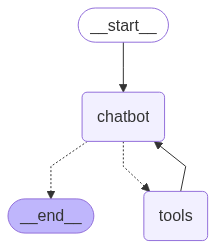

In [97]:
# Add nodes for chatbot and tools
workflow.add_node("chatbot", call_model)
workflow.add_node("tools", tool_node)

# Define an edge connecting START to the chatbot
workflow.add_edge(START, "chatbot")

# Define conditional edges and route "tools" back to "chatbot"
workflow.add_conditional_edges("chatbot", should_continue, ["tools", END])
workflow.add_edge("tools", "chatbot")

# Set up memory and compile the workflow
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))

### Section 3.3 - Organie chatbot outputs with memory

#### Configure outputs for multiple tools

Your chatbot's graph is ready to go! Now you can test how the chatbot works with different queries that should require different tools. To manage your chatbot's messages, the following modules have already been imported and your chatbot's config parameters have been set for one session.

In [101]:
from langchain_core.messages import AIMessage, HumanMessage

config = {"configurable": {"thread_id": "1"}}

In [104]:
# Create input message with the user's query
def multi_tool_output(query):
    inputs = {"messages": [HumanMessage(content=query)]}
    
    # Stream messages and metadata from the chatbot application
    for msg, metadata in app.stream(inputs, config, stream_mode="messages"):
        
        # Check if the message has content and is not from a human
        #print(msg)
        if msg.content and not isinstance(msg, HumanMessage):
            print(msg.content, end="", flush=True)    
    print("\n")

# Call the chatbot with different tools
multi_tool_output("Is `may a moody baby doom a yam` a palindrome?")
multi_tool_output("What happened on 20th July, 1969?")

Yes, the phrase "may a moody baby doom a yam" is indeed a palindrome.

On July 20, 1969, the Apollo 11 mission successfully landed the first humans on the Moon. Astronauts Neil Armstrong and Buzz Aldrin became the first and second humans to walk on the lunar surface, while Michael Collins orbited the Moon in the command module. Neil Armstrong's famous words, "That's one small step for [a] man, one giant leap for mankind," were broadcast to millions of people around the world. This event was a significant milestone in space exploration and a key moment in the Space Race between the United States and the Soviet Union.



#### Enable multi-turn conversation with memory
You are just about ready to share your chatbot update with the school administration! For students to have a smooth learning experience, it's important to enable them to ask follow-up questions. This way, if any information is missing from the chatbot's first answer, the students can modify their questions by having a conversation. You'll now adapt your chatbot's streaming function to enable multiple turns, printing both the user's query as well as the chatbot's answer. To enable memory, LangGraph will send the full conversation to the LLM when follow-up questions are asked. To start with, your `config` parameters have already been set for one user:

In [105]:
config = {"configurable": {"thread_id": "1"}}

In [106]:
# Print the user query first for every interaction 
def user_agent_multiturn(queries):
    for query in queries:
        print(f"User: {query}")
        
        # Stream through messages corresponding to queries, excluding metadata 
        print("Agent: " + "".join(msg.content for msg, metadata in app.stream(
                {"messages": [HumanMessage(content=query)]}, config, stream_mode="messages") 
            
            # Filter out the human messages to print agent messages
            if msg.content and not isinstance(msg, HumanMessage)) + "\n")     

queries = ["Is `stressed desserts?` a palindrome?", "What about the word `kayak`?",
    "What happened on the May 8th, 1945?", "What about 9 November 1989?"]
user_agent_multiturn(queries)

User: Is `stressed desserts?` a palindrome?
Agent: The phrase or word 'stressed desserts?' is a palindrome.Yes, the phrase "stressed desserts?" is a palindrome.

User: What about the word `kayak`?
Agent: The phrase or word 'kayak' is a palindrome.Yes, the word "kayak" is a palindrome.

User: What happened on the May 8th, 1945?
Agent: On May 8, 1945, an important historical event took place: **V-E Day (Victory in Europe Day)**. This day marked the formal acceptance of Nazi Germany's unconditional surrender by the Allied forces, effectively ending World War II in Europe. Celebrations erupted across the Allied nations, as people rejoiced over the defeat of Hitler and the end of years of conflict in Europe. The surrender was signed on May 7, 1945, but the news reached the public on May 8, leading to widespread celebrations and commemorations of the victory.On May 8, 1945, an important historical event took place: **V-E Day (Victory in Europe Day)**. This day marked the formal acceptance of